# Dynamic Operability Analysis: Pyomo + Orthogonal Collocation

This example runs a dynamic operability analysis with a **Pyomo DAE model** discretized by **orthogonal collocation on finite elements** as the step model. `make_pyomo_step_model` turns a Pyomo model builder into a step callable for `dynamic_operability`.

The system is a nonisothermal CSTR with a first-order irreversible reaction $A \to B$, with states $x_1$ (dimensionless concentration) and $x_2$ (dimensionless temperature) and inputs $u_1$ (feed concentration) and $u_2$ (coolant temperature):

$$\frac{dx_1}{dt} = \frac{1}{\theta}(u_1 - x_1) - Da \cdot x_1 \cdot \exp\!\left(\frac{x_2}{1 + x_2/\gamma}\right)$$

$$\frac{dx_2}{dt} = \frac{1}{\theta}(-x_2) + B \cdot Da \cdot x_1 \cdot \exp\!\left(\frac{x_2}{1 + x_2/\gamma}\right) - \beta(x_2 - u_2)$$

Parameters: $Da = 0.072$ (Damkohler number), $\gamma = 20$ (activation energy), $B = 8$ (heat of reaction), $\beta = 0.3$ (heat transfer), $\theta = 20$ (residence time).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae

from opyrability import (
    dynamic_operability_mapping,
    dOI_eval,
    plot_dynamic_funnel,
    simulate_mc_trajectories,
    make_pyomo_step_model,
)

## Step 1: Pyomo DAE model builder

A function builds a Pyomo `ConcreteModel` for one CSTR time step, discretizing the ODEs over $[0, \Delta t]$ by orthogonal collocation. It exposes `m.x_current` (current state, a `Param`), `m.u` (inputs), `m.x_next` (next state, a `Var`), and the constraints linking them through the DAE.

In [2]:
# CSTR parameters
Da = 0.072     # Damkohler number
gamma = 20.0   # Activation energy parameter
B_rxn = 8.0    # Dimensionless heat of reaction
beta = 0.3     # Heat transfer coefficient
theta = 20.0   # Residence time
dt = 0.5       # Time step size (small for fine resolution in the early transient)

n_x = 2  # States: concentration, temperature
n_u = 2  # Inputs: feed concentration, coolant temperature


def build_cstr_step():
    """
    Build a Pyomo model for one CSTR time step, discretized by collocation.

    The two CSTR ODEs are integrated over a single step ``[0, dt]`` using
    orthogonal collocation on finite elements (3 elements, 3 Lagrange-Radau
    points). The model exposes ``x_current`` (current state, set before each
    solve), ``u`` (inputs), and ``x_next`` (state at the end of the step),
    linked by the discretized dynamics.

    Returns
    -------
    pyomo.environ.ConcreteModel
        The single-step CSTR model, ready to solve once ``x_current`` and
        ``u`` are fixed.
    """
    m = pyo.ConcreteModel()

    # Time domain for a single step [0, dt]
    m.t = dae.ContinuousSet(bounds=(0, dt))

    # Index sets
    m.state_idx = pyo.RangeSet(0, n_x - 1)
    m.input_idx = pyo.RangeSet(0, n_u - 1)

    # Current state (parameters, set before each solve)
    m.x_current = pyo.Param(m.state_idx, initialize=0.0, mutable=True)

    # Inputs (fixed before each solve)
    m.u = pyo.Var(m.input_idx, initialize=0.0)

    # State profiles over [0, dt]
    m.x1 = pyo.Var(m.t, initialize=1.0)  # concentration
    m.x2 = pyo.Var(m.t, initialize=0.0)  # temperature

    # Derivatives
    m.dx1dt = dae.DerivativeVar(m.x1, wrt=m.t)
    m.dx2dt = dae.DerivativeVar(m.x2, wrt=m.t)

    # ODEs
    @m.Constraint(m.t)
    def ode_x1(m, t):
        if t == 0:
            return pyo.Constraint.Skip
        r = Da * m.x1[t] * pyo.exp(m.x2[t] / (1 + m.x2[t] / gamma))
        return m.dx1dt[t] == (1.0 / theta) * (m.u[0] - m.x1[t]) - r

    @m.Constraint(m.t)
    def ode_x2(m, t):
        if t == 0:
            return pyo.Constraint.Skip
        r = Da * m.x1[t] * pyo.exp(m.x2[t] / (1 + m.x2[t] / gamma))
        return m.dx2dt[t] == (1.0 / theta) * (-m.x2[t]) + B_rxn * r - beta * (m.x2[t] - m.u[1])

    # Initial conditions (linked to x_current parameters)
    @m.Constraint()
    def ic_x1(m):
        return m.x1[0] == m.x_current[0]

    @m.Constraint()
    def ic_x2(m):
        return m.x2[0] == m.x_current[1]

    # Apply collocation discretization: 3 finite elements, 3 collocation points
    discretizer = pyo.TransformationFactory('dae.collocation')
    discretizer.apply_to(m, nfe=3, ncp=3, scheme='LAGRANGE-RADAU')

    # Next state = final value of state profiles
    m.x_next = pyo.Var(m.state_idx, initialize=0.0)

    @m.Constraint()
    def link_x_next_0(m):
        return m.x_next[0] == m.x1[dt]

    @m.Constraint()
    def link_x_next_1(m):
        return m.x_next[1] == m.x2[dt]

    # Dummy objective (feasibility problem)
    m.obj = pyo.Objective(expr=0)

    return m


print("CSTR Pyomo model builder defined.")
print(f"States: x1 (concentration), x2 (temperature)")
print(f"Inputs: u1 (feed conc.), u2 (coolant temp.)")
print(f"Time step dt = {dt}")

CSTR Pyomo model builder defined.
States: x1 (concentration), x2 (temperature)
Inputs: u1 (feed conc.), u2 (coolant temp.)
Time step dt = 0.5


## Step 2: Wrap the builder with `make_pyomo_step_model`

The wrapper builds the model, sets `x_current` and `u`, solves with IPOPT, and returns `x_next`.

In [3]:
step_model = make_pyomo_step_model(build_cstr_step,
                                   n_x=n_x,
                                   n_u=n_u)

# Test the step model with a single step. make_pyomo_step_model returns
# a (x_next, y) tuple; the output y defaults to the identity (y = x_next).
x_test = np.array([1.0, 0.0])    # initial: feed conc=1, temp=0
u_test = np.array([1.0, 0.0])    # nominal inputs
x_next_test, y_test = step_model(x_test, u_test)
print(f"Test step: x0 = {x_test} -> x1 = {x_next_test}")

Test step: x0 = [1. 0.] -> x1 = [0.95949 0.30199]


## Step 3: Outputs and operability sets

The outputs are the states themselves ($y = x$). We set the AIS (feed concentration $u_1 \in [0.8, 1.2]$, coolant temperature $u_2 \in [-0.5, 0.5]$), the DOS (concentration $y_1 \in [0.1, 0.5]$, temperature $y_2 \in [-0.2, 2.0]$), and the initial state $x_0 = (1.0, 0.0)$.

In [4]:
# Initial state (fresh feed, ambient temperature)
x0 = np.array([1.0, 0.0])

# Available Input Set bounds
AIS_bounds = np.array([
    [0.8, 1.2],    # u1: feed concentration
    [-0.5, 0.5],   # u2: coolant temperature
])

# Desired Output Set bounds (covers the steady-state AOS range)
DOS_bounds = np.array([
    [0.1, 0.5],    # y1: concentration
    [-0.2, 2.0],   # y2: temperature
])

# With dt=0.5, k_max=48 covers 24 time units total.
# This gives fine resolution in the early transient (many polytopes
# between k=0 and k=10, i.e. t=0 to t=5).
k_max = 48

print(f"Initial state: x0 = {x0}")
print(f"AIS bounds: {AIS_bounds.tolist()}")
print(f"DOS bounds: {DOS_bounds.tolist()}")
print(f"Max time steps: {k_max} (total time = {k_max * dt})")

Initial state: x0 = [1. 0.]
AIS bounds: [[0.8, 1.2], [-0.5, 0.5]]
DOS bounds: [[0.1, 0.5], [-0.2, 2.0]]
Max time steps: 48 (total time = 24.0)


## Step 4: Run the dynamic operability analysis

`dynamic_operability_mapping` propagates the achievable output set forward by nonlinear state-space projection (vertex enumeration plus convex hull), and `dOI_eval` scores it against the DOS at each step. We use a scipy step model equivalent to the Pyomo collocation model (validated in Step 6), because running many time steps with Pyomo/IPOPT would be slow, as each vertex needs an NLP solve.

No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.
No intersection found between AS and DS. OI = 0.


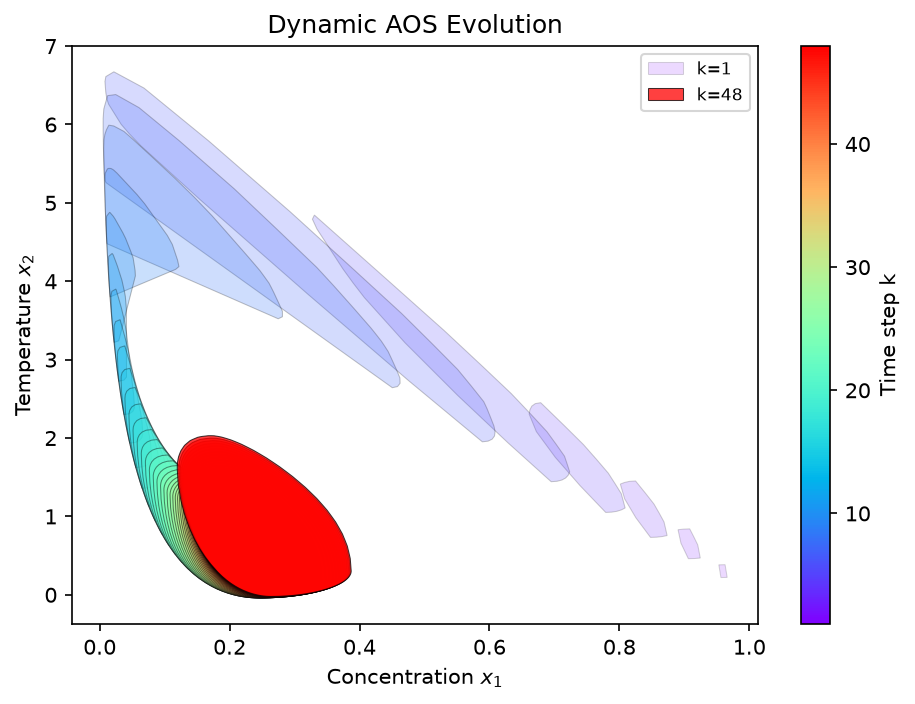

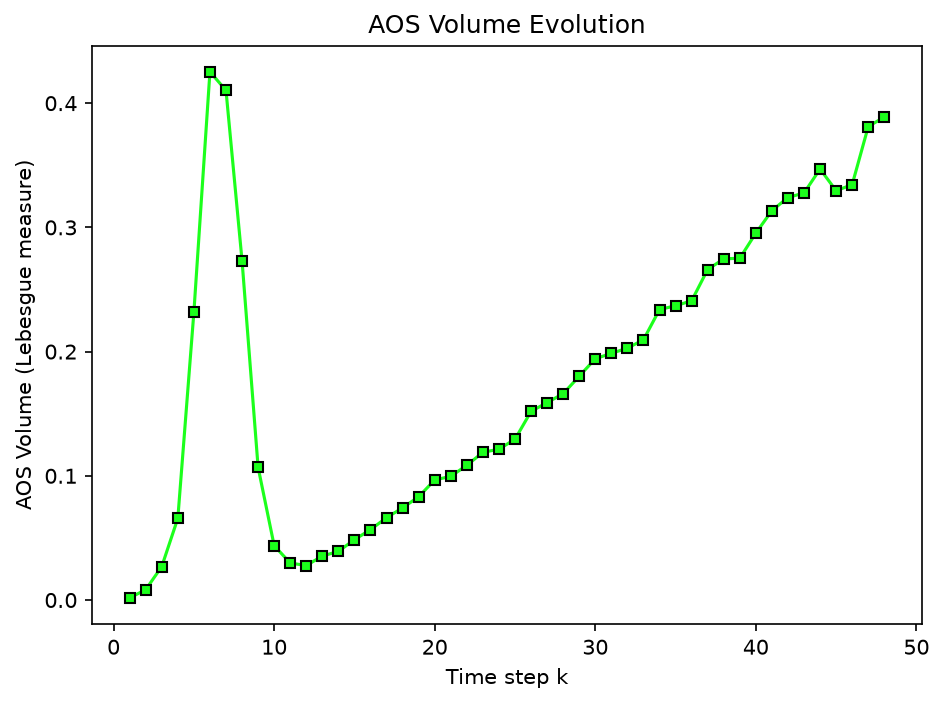

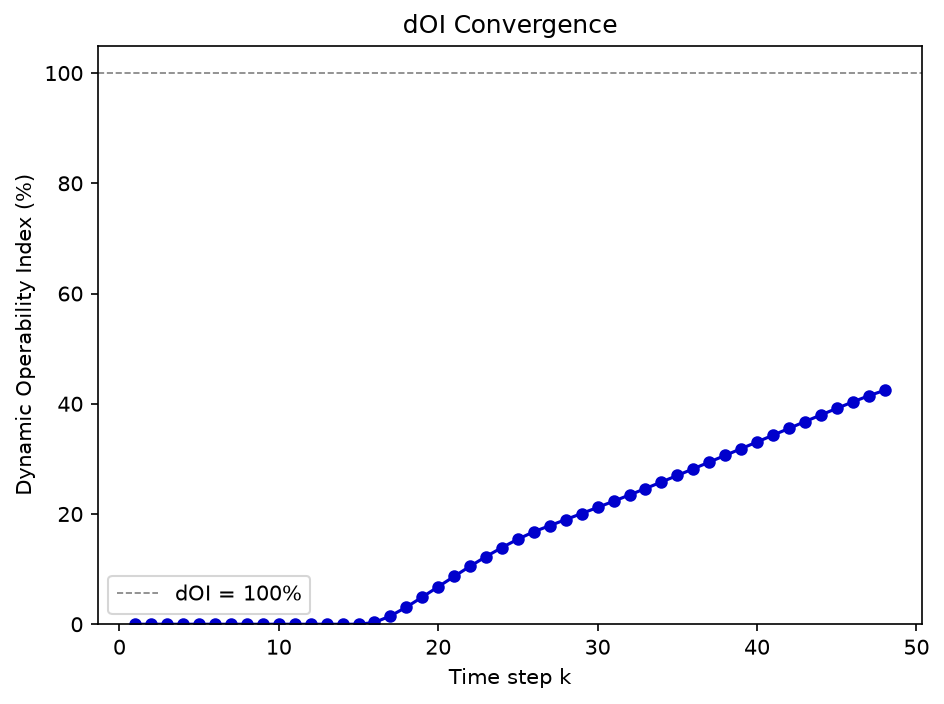

In [5]:
from scipy.integrate import solve_ivp

def cstr_rhs(t, x, u):
    """
    Right-hand side of the CSTR ODEs, dx/dt = f(x, u).

    Parameters
    ----------
    t : float
        Time (unused; the dynamics are autonomous).
    x : array-like, shape (2,)
        State ``[concentration, temperature]``.
    u : array-like, shape (2,)
        Inputs ``[feed concentration, coolant temperature]``.

    Returns
    -------
    list of float
        The derivative ``[dx1/dt, dx2/dt]``.
    """
    x1, x2 = x
    r = Da * x1 * np.exp(x2 / (1 + x2 / gamma))
    dx1 = (1.0 / theta) * (u[0] - x1) - r
    dx2 = (1.0 / theta) * (-x2) + B_rxn * r - beta * (x2 - u[1])
    return [dx1, dx2]


def step_model_scipy(x, u):
    """
    Advance the CSTR by one step ``dt`` with a direct scipy integration.

    This is the scipy equivalent of the Pyomo collocation step model, used for
    speed in the mapping; Step 6 checks that the two agree.

    Parameters
    ----------
    x : array-like, shape (2,)
        Current state.
    u : array-like, shape (2,)
        Inputs held constant over the step.

    Returns
    -------
    x_next : numpy.ndarray, shape (2,)
        State at the end of the step.
    y : numpy.ndarray, shape (2,)
        Output, here the identity ``y = x_next``.
    """
    sol = solve_ivp(cstr_rhs, [0, dt], x, args=(u,),
                    method='RK45', rtol=1e-8)
    x_next = sol.y[:, -1]
    return x_next, x_next

# Mapping stage: propagate the AOS forward through the CSTR dynamics.
results = dynamic_operability_mapping(step_model_scipy,
                                      x0,
                                      AIS_bounds,
                                      3,
                                      k_max,
                                      convergence_tol=1e-3,
                                      plot=True,
                                      labels=['Concentration $x_1$', 'Temperature $x_2$'])

# Evaluation stage: dOI at each k.
dOI = dOI_eval(results,
               DOS_bounds,
               plot=True)

In [6]:
print(f"Converged at step k = {results['k_converged']}")
print(f"Final AOS volume = {results['volumes'][-1]:.4f}")
print(f"Final dOI = {dOI[-1]:.2f}%")
print(f"\ndOI trajectory:")
for k, d in enumerate(dOI):
    print(f"  k={k+1}: dOI = {d:.2f}%")

Converged at step k = None
Final AOS volume = 0.3888
Final dOI = 42.44%

dOI trajectory:
  k=1: dOI = 0.00%
  k=2: dOI = 0.00%
  k=3: dOI = 0.00%
  k=4: dOI = 0.00%
  k=5: dOI = 0.00%
  k=6: dOI = 0.00%
  k=7: dOI = 0.00%
  k=8: dOI = 0.00%
  k=9: dOI = 0.00%
  k=10: dOI = 0.00%
  k=11: dOI = 0.00%
  k=12: dOI = 0.00%
  k=13: dOI = 0.00%
  k=14: dOI = 0.00%
  k=15: dOI = 0.00%
  k=16: dOI = 0.32%
  k=17: dOI = 1.51%
  k=18: dOI = 3.10%
  k=19: dOI = 4.93%
  k=20: dOI = 6.81%
  k=21: dOI = 8.68%
  k=22: dOI = 10.53%
  k=23: dOI = 12.28%
  k=24: dOI = 13.92%
  k=25: dOI = 15.44%
  k=26: dOI = 16.78%
  k=27: dOI = 17.90%
  k=28: dOI = 18.99%
  k=29: dOI = 20.09%
  k=30: dOI = 21.20%
  k=31: dOI = 22.32%
  k=32: dOI = 23.46%
  k=33: dOI = 24.62%
  k=34: dOI = 25.80%
  k=35: dOI = 27.00%
  k=36: dOI = 28.20%
  k=37: dOI = 29.42%
  k=38: dOI = 30.63%
  k=39: dOI = 31.85%
  k=40: dOI = 33.07%
  k=41: dOI = 34.30%
  k=42: dOI = 35.53%
  k=43: dOI = 36.76%
  k=44: dOI = 37.97%
  k=45: dOI = 39.

## Step 5: Dynamic operability funnel

Stacking the achievable output sets along the time axis gives the funnel, overlaid here with Monte Carlo trajectories from random input sequences.

In [7]:
# Monte Carlo trajectories (step model is read from the results dict).
mc_trajs = simulate_mc_trajectories(results,
                                    n_trajectories=100,
                                    seed=42)

fig, _ = plot_dynamic_funnel(results,
                             DOS=DOS_bounds,
                             labels=['Concentration x<sub>1</sub>', 'Temperature x<sub>2</sub>'],
                             alpha=0.3,
                             view_elev=25,
                             view_azim=-55,
                             mc_trajectories=mc_trajs,
                             mc_color='green',
                             mc_alpha=0.3,
                             mc_linewidth=0.5,
                             engine='plotly')

## Step 6: Validate collocation against scipy integration

Comparing the Pyomo collocation step against a direct scipy ODE integration checks that the collocation discretization is accurate.

In [8]:
# Compare Pyomo collocation step vs scipy RK45 step for several input combinations.
# Both step callables return (x_next, y) tuples; we unpack the state component here.
test_inputs = [
    ([1.0, 0.0], [1.0, 0.0]),
    ([1.0, 0.0], [0.8, -0.5]),
    ([1.0, 0.0], [1.2, 0.5]),
    ([0.9, 1.0], [1.0, 0.0]),
]

print(f"{'x0':>20s}  {'u':>20s}  {'Pyomo x_next':>25s}  {'Scipy x_next':>25s}  {'Max error':>10s}")
print("-" * 110)
for x_t, u_t in test_inputs:
    x_pyomo, _ = step_model(np.array(x_t), np.array(u_t))
    x_scipy, _ = step_model_scipy(np.array(x_t), np.array(u_t))
    err = np.max(np.abs(x_pyomo - x_scipy))
    print(f"{str(x_t):>20s}  {str(u_t):>20s}  {np.array2string(x_pyomo, precision=6):>25s}  "
          f"{np.array2string(x_scipy, precision=6):>25s}  {err:>10.2e}")

                  x0                     u               Pyomo x_next               Scipy x_next   Max error
--------------------------------------------------------------------------------------------------------------
          [1.0, 0.0]            [1.0, 0.0]        [0.959491 0.301993]        [0.959491 0.301993]    3.10e-10
          [1.0, 0.0]           [0.8, -0.5]        [0.95624  0.220313]        [0.95624  0.220313]    1.12e-10
          [1.0, 0.0]            [1.2, 0.5]        [0.962647 0.384403]        [0.962647 0.384403]    6.75e-10
          [0.9, 1.0]            [1.0, 0.0]        [0.800767 1.59911 ]        [0.800767 1.59911 ]    1.86e-08


## Summary

This example:

1. built a **Pyomo DAE model** with orthogonal collocation for a nonisothermal CSTR;
2. wrapped it with **`make_pyomo_step_model`** into a step callable;
3. ran **`dynamic_operability_mapping`** and **`dOI_eval`** on the resulting step model;
4. visualized the evolving AOS, the dOI trajectory, and the 3D funnel;
5. validated the collocation step against direct ODE integration.

`make_pyomo_step_model` lets any Pyomo optimization model serve as the step model for dynamic operability, bringing Pyomo's DAE and collocation tools into the framework.